# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Kadek Nathania Gavrila Astika| 5054251050|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [32]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [36]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')

# 1. Jumlah baris dan kolom
print("Jumlah baris dan kolom:", df.shape)

# 2. Tipe data
print("\nTipe Data")
print(df.dtypes)

# 3. Statistik deskriptif
print("\nStatistik Deskriptif")
display(df.describe())

# 4. Jumlah missing value
print("\nMissing Value")
print(df.isnull().sum())

df.info()

Jumlah baris dan kolom: (768, 9)

Tipe Data
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Statistik Deskriptif


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Missing Value
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    i

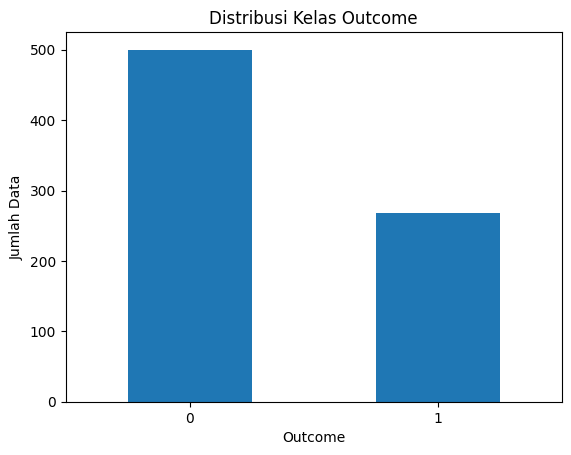

Jumlah data tiap kelas:
Outcome
0    500
1    268
Name: count, dtype: int64

Persentase tiap kelas:
Outcome
0    65.1
1    34.9
Name: count, dtype: float64


In [4]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
outcome_counts = df['Outcome'].value_counts().sort_index()

# Bar plot
outcome_counts.plot(kind='bar')

plt.title('Distribusi Kelas Outcome')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

# Tampilkan jumlah dan persentase tiap kelas
print("Jumlah data tiap kelas:")
print(outcome_counts)

print("\nPersentase tiap kelas:")
print((outcome_counts / len(df) * 100).round(2))

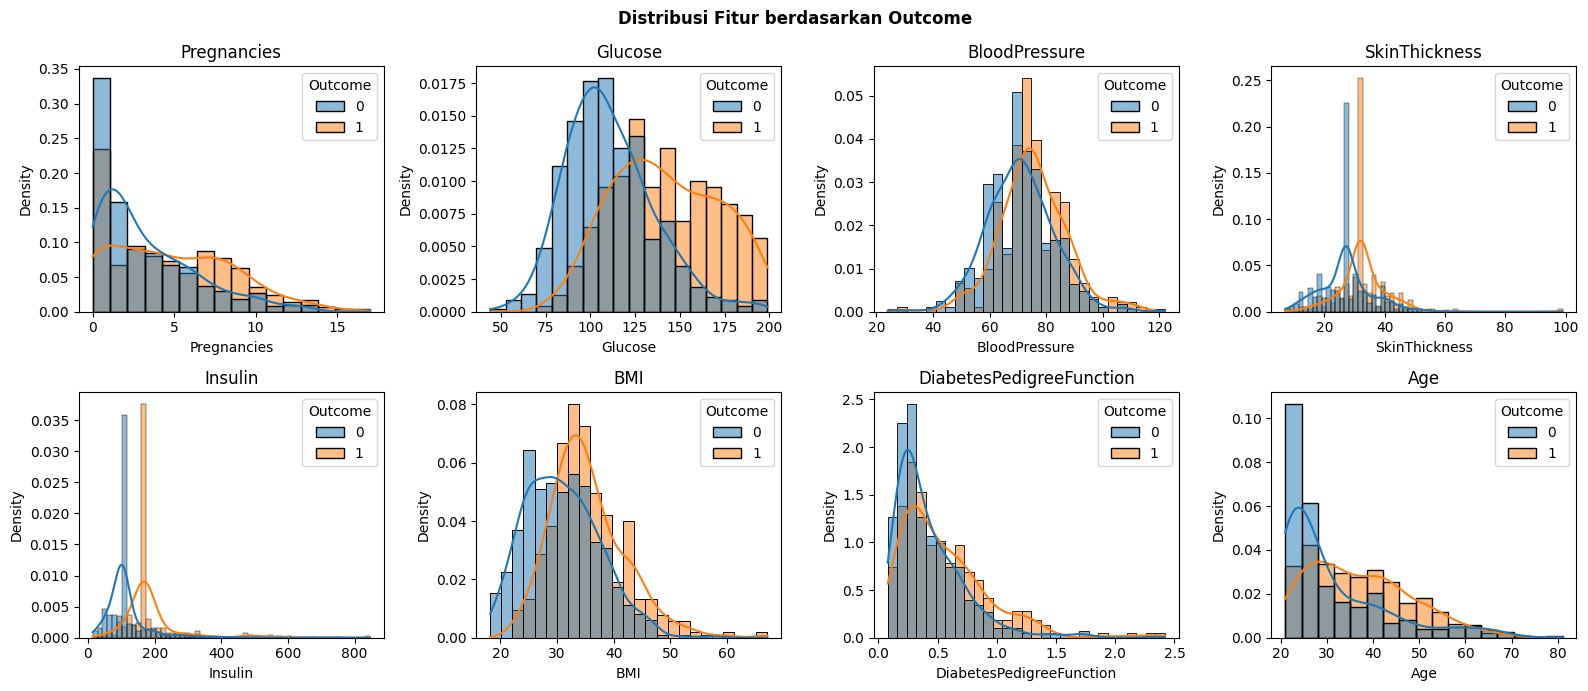

In [6]:
#  Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = df.columns.drop('Outcome')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.flat, features):
    sns.histplot(
        data=df,
        x=col,
        hue='Outcome',
        kde=True,
        stat='density',
        common_norm=False,
        ax=ax
    )
    ax.set_title(col)

plt.suptitle('Distribusi Fitur berdasarkan Outcome', fontweight='bold')
plt.tight_layout()
plt.show()


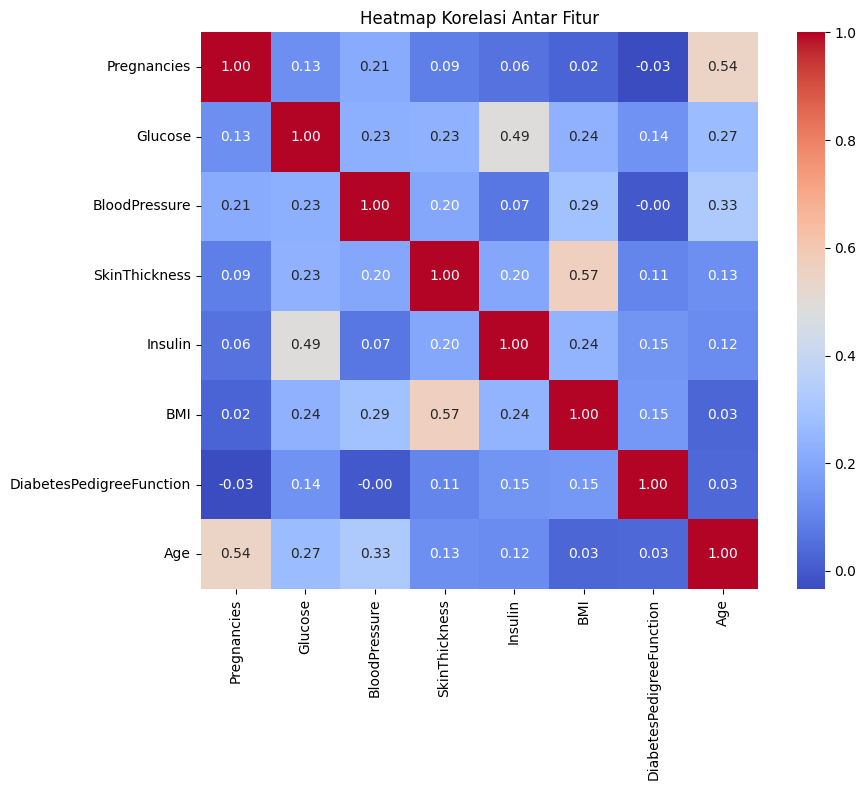

In [7]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(10, 8))

correlation = df.drop(columns='Outcome').corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)

plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [12]:
# Korelasi setiap fitur dengan Outcome
target_corr = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)

print("Korelasi fitur dengan Outcome:")
display(target_corr)

Korelasi fitur dengan Outcome:


Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64

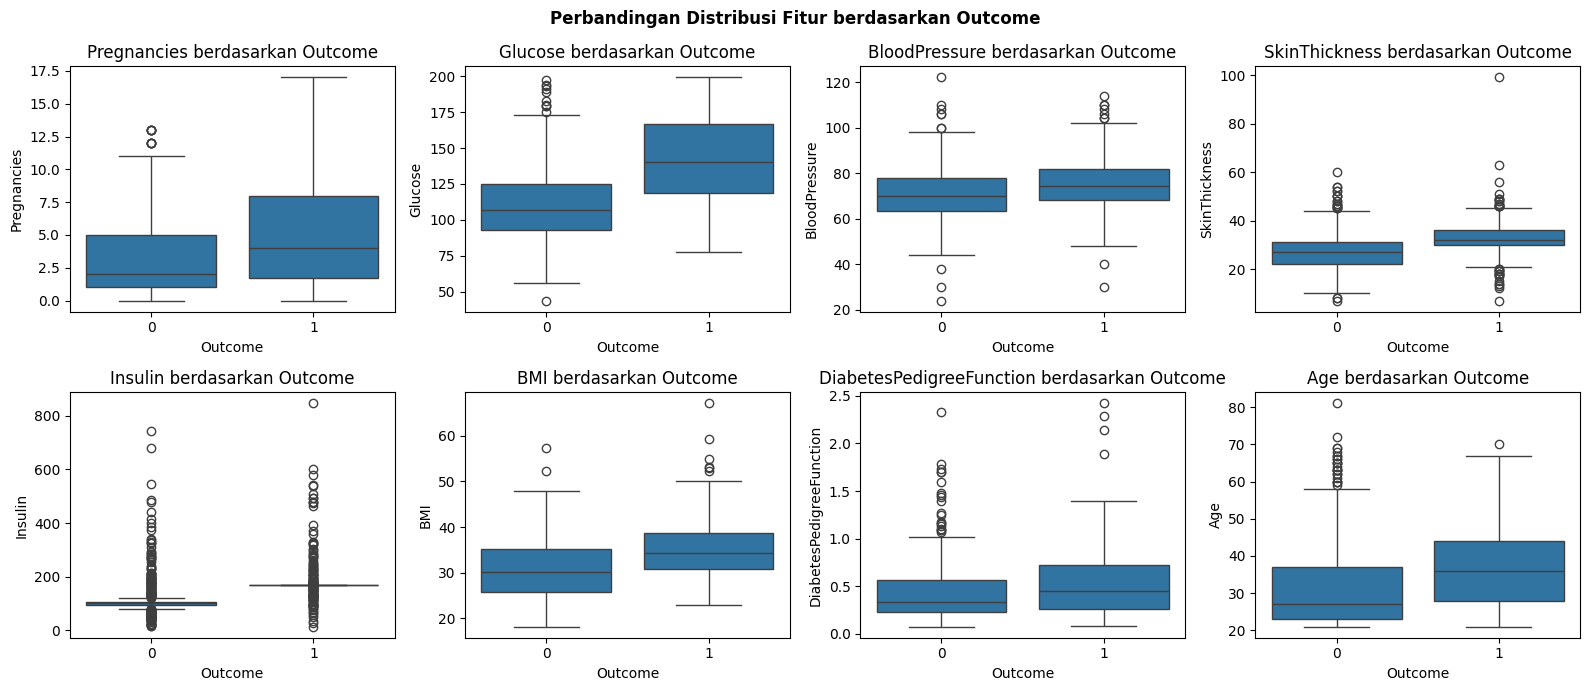

In [ ]:
# Boxplot setiap fitur berdasarkan Outcome

features = df.columns.drop('Outcome')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x='Outcome', y=col, ax=ax)
    ax.set_title(f'{col} berdasarkan Outcome')
    ax.set_xlabel('Outcome')
    ax.set_ylabel(col)

plt.suptitle('Perbandingan Distribusi Fitur berdasarkan Outcome', fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Cek skewness setiap fitur
skewness = df.drop(columns='Outcome').skew().sort_values(ascending=False)

print("Skewness setiap fitur:")
display(skewness)

Skewness setiap fitur:


Insulin                     3.028046
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.817477
BMI                         0.606416
Glucose                     0.532324
BloodPressure               0.140830
dtype: float64

# 2. Preprocessing

In [15]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_summary = pd.DataFrame({
    'Jumlah Nilai 0': (df[cols_with_zero] == 0).sum(),
    'Persentase (%)': ((df[cols_with_zero] == 0).sum() / len(df) * 100).round(2)
})

display(zero_summary)

,Jumlah Nilai 0,Persentase (%)
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0


In [17]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Pisahkan fitur dan target
X = df.drop(columns='Outcome')
y = df['Outcome']

# Split data terlebih dahulu untuk menghindari data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Kolom yang memiliki nilai 0 yang tidak valid
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Ubah nilai 0 menjadi NaN
X_train[cols_with_zero] = X_train[cols_with_zero].replace(0, np.nan)
X_test[cols_with_zero] = X_test[cols_with_zero].replace(0, np.nan)

# Imputasi menggunakan median
imputer = SimpleImputer(strategy='median')

X_train[cols_with_zero] = imputer.fit_transform(X_train[cols_with_zero])
X_test[cols_with_zero] = imputer.transform(X_test[cols_with_zero])

print("Missing value setelah imputasi:")
print(X_train.isnull().sum())

Missing value setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [18]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns='Outcome')
y = df['Outcome']

# Bagi data menjadi train set dan test set (80:20)
# stratify=y menjaga proporsi kelas Outcome tetap sama
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (614, 8)
Ukuran X_test : (154, 8)
Ukuran y_train: (614,)
Ukuran y_test : (154,)


In [20]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()

# Fit hanya pada train set, lalu transform train set
X_train_scaled = scaler.fit_transform(X_train)

# Transform test set menggunakan scaler dari train set
X_test_scaled = scaler.transform(X_test)

print("Ukuran X_train_scaled:", X_train_scaled.shape)
print("Ukuran X_test_scaled :", X_test_scaled.shape)

Ukuran X_train_scaled: (614, 8)
Ukuran X_test_scaled : (154, 8)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [23]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [25]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_scaled)
y_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [27]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [28]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [31]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Evaluasi Gaussian Naive Bayes
print("Gaussian Naive Bayes")
print("Accuracy :", accuracy_score(y_test, y_pred_gnb))
print("Precision:", precision_score(y_test, y_pred_gnb))
print("Recall   :", recall_score(y_test, y_pred_gnb))
print("F1-Score :", f1_score(y_test, y_pred_gnb))

# Evaluasi Logistic Regression
print("\nLogistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))

Gaussian Naive Bayes
Accuracy : 0.7272727272727273
Precision: 0.603448275862069
Recall   : 0.6481481481481481
F1-Score : 0.625

Logistic Regression
Accuracy : 0.7077922077922078
Precision: 0.5882352941176471
Recall   : 0.5555555555555556
F1-Score : 0.5714285714285714


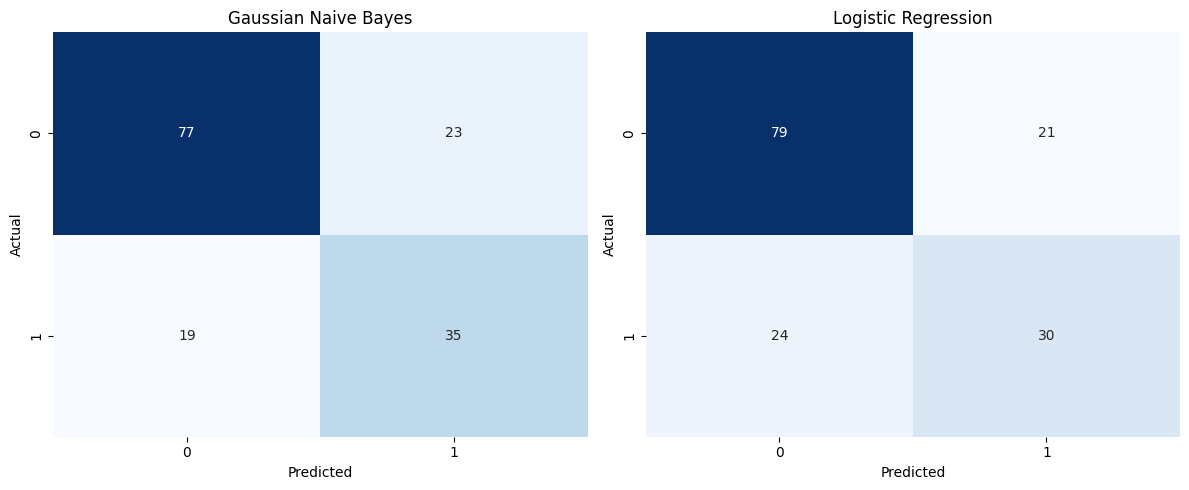

In [33]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Hitung confusion matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Tampilkan confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Gaussian Naive Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

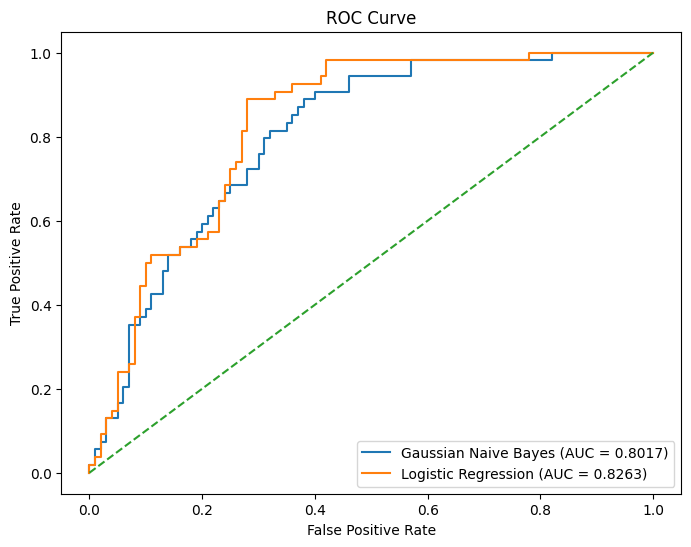

In [34]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
# Hitung ROC Curve
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

# Hitung AUC
auc_gnb = roc_auc_score(y_test, y_proba_gnb)
auc_lr = roc_auc_score(y_test, y_proba_lr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian Naive Bayes (AUC = {auc_gnb:.4f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

# Garis baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

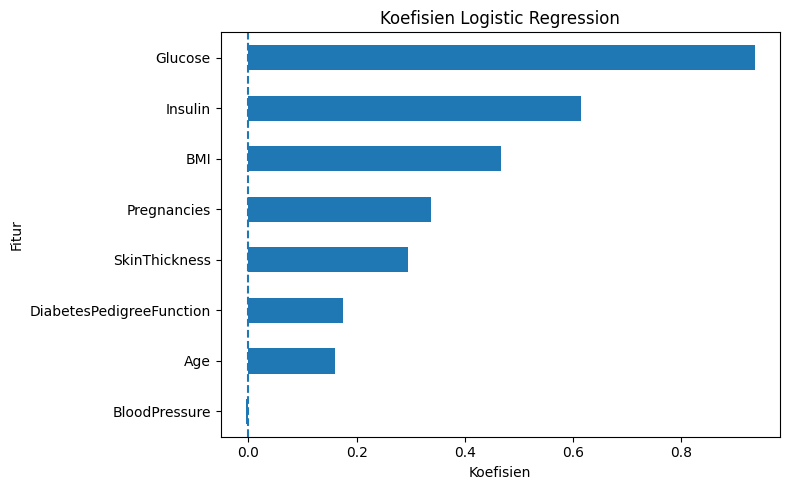

In [35]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
# Ambil koefisien Logistic Regression
coefficients = lr.coef_[0]

# Buat Series dengan nama fitur
coef_series = pd.Series(coefficients, index=X.columns).sort_values()

# Plot koefisien
plt.figure(figsize=(8, 5))

coef_series.plot(kind='barh')

plt.title('Koefisien Logistic Regression')
plt.xlabel('Koefisien')
plt.ylabel('Fitur')
plt.axvline(x=0, linestyle='--')

plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan eksperimen, dataset terdiri dari **768 data dengan 8 fitur dan 1 target (Outcome)** tanpa missing value secara langsung. Dari hasil EDA, **Glucose** memiliki korelasi paling tinggi dengan Outcome, sedangkan **Insulin** memiliki distribusi paling skewed. Pada preprocessing, nilai 0 pada fitur **Glucose, BloodPressure, SkinThickness, Insulin, dan BMI** dianggap tidak valid, kemudian diganti dengan median dan seluruh fitur distandardisasi.

Hasil evaluasi menunjukkan bahwa **Gaussian Naive Bayes** memiliki performa lebih baik daripada **Logistic Regression** pada seluruh metrik. Gaussian Naive Bayes memperoleh **Accuracy 0.7273, Precision 0.6034, Recall 0.6481, F1-Score 0.6250, dan AUC 0.9017**, sedangkan Logistic Regression memperoleh **Accuracy 0.7078, Precision 0.5882, Recall 0.5556, F1-Score 0.5714, dan AUC 0.8263**.

Dengan demikian, pada eksperimen yang dilakukan, **Gaussian Naive Bayes memberikan hasil klasifikasi yang lebih baik** setelah melalui tahapan EDA, preprocessing, dan evaluasi model.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

Berdasarkan hasil eksperimen, **Gaussian Naive Bayes memiliki performa lebih baik dibandingkan Logistic Regression** pada dataset yang digunakan. Tahap preprocessing dengan menangani nilai 0 yang tidak valid menggunakan **median imputation**, kemudian melakukan standardisasi, dapat digunakan untuk menyiapkan data sebelum klasifikasi.

### Saran

Eksperimen selanjutnya dapat membandingkan **metode imputasi dan transformasi data** lain, terutama karena beberapa fitur memiliki distribusi yang cukup skewed. Selain itu, dapat dilakukan **tuning hyperparameter, penggunaan model klasifikasi lain, dan cross-validation** untuk memperoleh hasil yang lebih optimal dan stabil.
